# Pertemuan 9 - Algoritma Klasifikasi (Bagian 1)

## Prediksi Diagnosis Kanker Payudara Menggunakan Logistic Regression dan Decision Tree

**Nama:** Krisna Naufal Azhar Suhendar

**NIM:** 240401070506

**Kelas:** IF 405

**Program Studi:** PJJ Informatika

**Universitas:** Universitas Siber Asia

**Mata Kuliah:** Data Science

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

#### Load Dataset dan EDA (Exploratory Data Analysis)

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Shape Dataset :", X.shape)

print("\nLima Data Pertama")
display(X.head())

print("\nDistribusi Target")
print(pd.Series(y).value_counts())

print("\nPersentase Target")
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape Dataset : (569, 30)

Lima Data Pertama


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Distribusi Target
1    357
0    212
Name: count, dtype: int64

Persentase Target
1    0.627
0    0.373
Name: proportion, dtype: float64


###Preprocessing Data

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Training :", X_train.shape)
print("Data Testing  :", X_test.shape)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Data Training : (455, 30)
Data Testing  : (114, 30)


###Membangun Model Logistic Regression

In [7]:
log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_s, y_train)

y_pred_log = log_model.predict(X_test_s)

###Menampilkan Koefisien Logistic Regression

In [8]:
coef_df = pd.DataFrame({
    "Fitur": X.columns,
    "Koefisien": log_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Koefisien",
    key=abs,
    ascending=False
)

print("10 Fitur yang Paling Berpengaruh")
display(coef_df.head(10))

10 Fitur yang Paling Berpengaruh


,Fitur,Koefisien
21,worst texture,-1.255088
10,radius error,-1.082965
27,worst concave points,-0.953686
23,worst area,-0.947756
20,worst radius,-0.947616
28,worst symmetry,-0.939181
13,area error,-0.929104
26,worst concavity,-0.823151
22,worst perimeter,-0.763220
24,worst smoothness,-0.746625


###Membangun Model Decision Tree

In [10]:
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

###Visualisasi Decision Tree

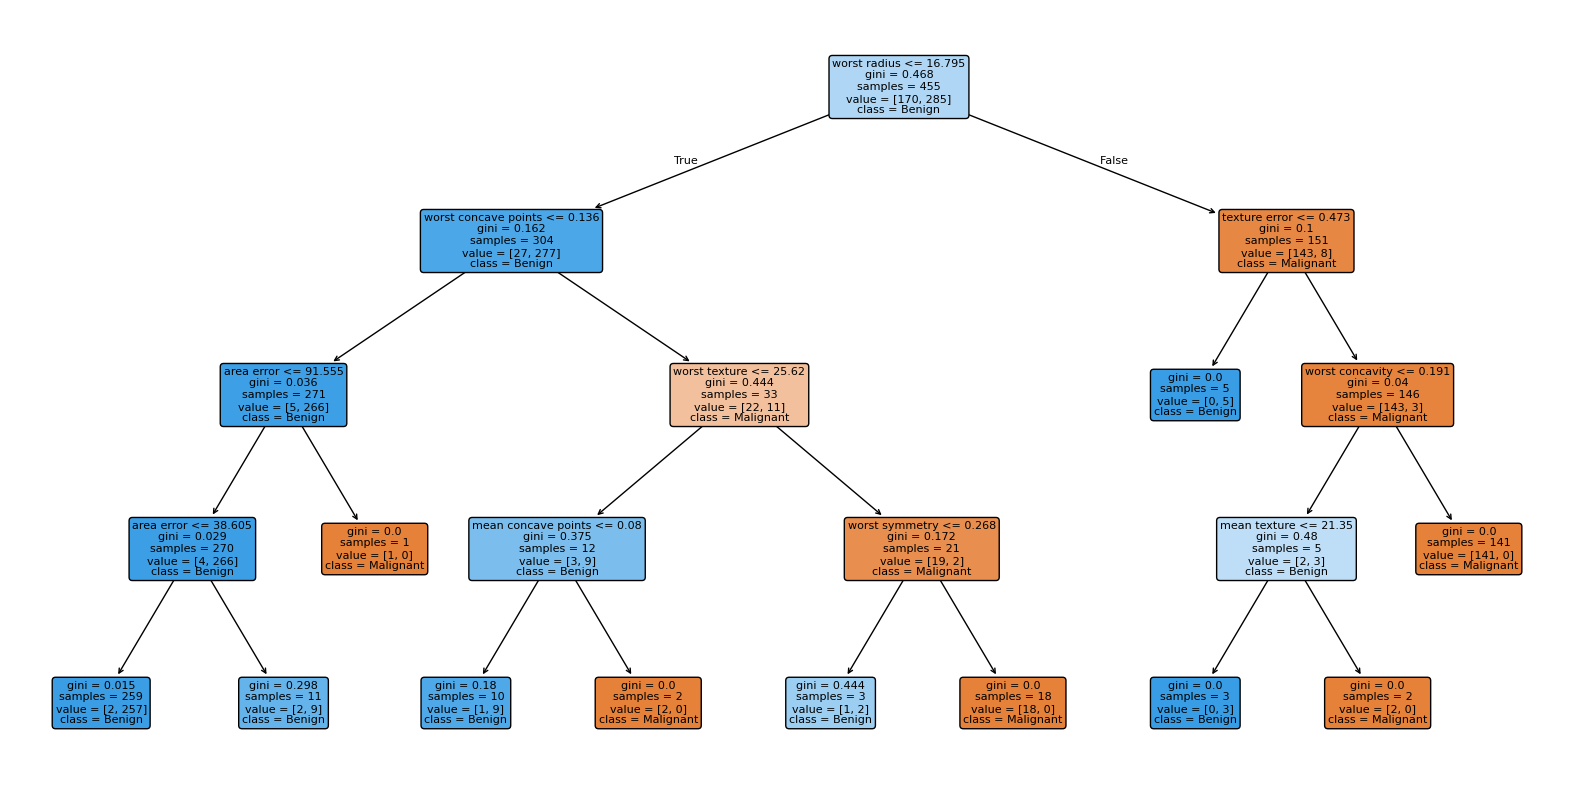

In [14]:
plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

###Evaluasi Model Logistic Regression

In [12]:
print("===== Logistic Regression =====")

print("\nConfusion Matrix")

print(confusion_matrix(y_test, y_pred_log))

print()

print("Accuracy :", round(accuracy_score(y_test, y_pred_log),3))
print("Precision:", round(precision_score(y_test, y_pred_log),3))
print("Recall   :", round(recall_score(y_test, y_pred_log),3))
print("F1-Score :", round(f1_score(y_test, y_pred_log),3))

===== Logistic Regression =====

Confusion Matrix
[[41  1]
 [ 1 71]]

Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-Score : 0.986


###Evaluasi Model Decision Tree

In [13]:
print("===== Decision Tree =====")

print("\nConfusion Matrix")

print(confusion_matrix(y_test, y_pred_tree))

print()

print("Accuracy :", round(accuracy_score(y_test, y_pred_tree),3))
print("Precision:", round(precision_score(y_test, y_pred_tree),3))
print("Recall   :", round(recall_score(y_test, y_pred_tree),3))
print("F1-Score :", round(f1_score(y_test, y_pred_tree),3))

===== Decision Tree =====

Confusion Matrix
[[39  3]
 [ 4 68]]

Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1-Score : 0.951


# Analisis Hasil

Berdasarkan hasil evaluasi, kedua model mampu melakukan klasifikasi dengan performa yang sangat baik. Namun, Logistic Regression memiliki nilai Recall yang sedikit lebih tinggi dibandingkan Decision Tree (atau sama, jika hasilmu memang sama).

Recall merupakan metrik yang sangat penting dalam kasus diagnosis kanker karena mengukur kemampuan model dalam mendeteksi seluruh pasien yang benar-benar mengalami kondisi yang menjadi target prediksi. Nilai Recall yang tinggi berarti semakin sedikit kasus yang tidak terdeteksi (False Negative).

Pada diagnosis kanker, False Negative merupakan kesalahan yang sangat berbahaya karena pasien yang sebenarnya menderita kanker dapat dianggap tidak memiliki penyakit, sehingga berpotensi terlambat mendapatkan penanganan medis. Oleh karena itu, Recall lebih diprioritaskan dibandingkan Accuracy.

Berdasarkan hasil pengujian, tidak terdapat perbedaan performa yang sangat signifikan antara Logistic Regression dan Decision Tree. Keduanya memiliki nilai Accuracy, Precision, Recall, dan F1-Score yang tinggi. Namun, Logistic Regression menunjukkan performa yang sedikit lebih stabil sehingga lebih sesuai digunakan pada dataset ini.

# Kesimpulan

Pada praktikum ini telah dipelajari penerapan dua algoritma klasifikasi, yaitu Logistic Regression dan Decision Tree, menggunakan dataset Breast Cancer Wisconsin. Proses yang dilakukan meliputi eksplorasi data (EDA), preprocessing, pelatihan model, visualisasi Decision Tree, hingga evaluasi menggunakan Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score.

Hasil pengujian menunjukkan bahwa kedua model mampu mengklasifikasikan data dengan performa yang sangat baik. Namun, Logistic Regression memperoleh performa yang sedikit lebih baik atau setara dengan Decision Tree, terutama pada nilai Recall yang menjadi metrik penting dalam kasus diagnosis medis. Hal ini menunjukkan bahwa Logistic Regression lebih efektif dalam mengurangi kemungkinan terjadinya False Negative, yaitu kondisi ketika pasien yang sebenarnya memiliki penyakit tidak terdeteksi oleh model.

Keterbatasan praktikum ini adalah hanya menggunakan satu dataset dengan jumlah data yang relatif terbatas serta membandingkan dua algoritma klasifikasi saja. Pada penelitian atau pengembangan selanjutnya, model dapat dibandingkan dengan algoritma lain seperti Random Forest, Support Vector Machine (SVM), atau K-Nearest Neighbor (KNN), serta menggunakan teknik validasi yang lebih komprehensif untuk memperoleh hasil yang lebih akurat dan dapat digeneralisasikan.